# Exploratory Data Analysis & Feature Extraction for Mobile Phones - NHIS Project 4

In [1]:
# importing modules
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

In [2]:
import pandas as pd

df = pd.read_csv(r"C:\mobile project\mobile_data.csv")
df.head()

,Unnamed: 0,Model,Colour,Memory,RAM,Battery_,Rear Camera,Front Camera,AI Lens,Mobile Height,Processor_,Prize
0,0,Infinix SMART 7,Night Black,64,4,6000,13MP,5MP,1,16.76,Unisoc Spreadtrum SC9863A1,"7,299"
1,1,Infinix SMART 7,Azure Blue,64,4,6000,13MP,5MP,1,16.76,Unisoc Spreadtrum SC9863A1,"7,299"
2,2,MOTOROLA G32,Mineral Gray,128,8,5000,50MP,16MP,0,16.64,Qualcomm Snapdragon 680,"11,999"
3,3,POCO C50,Royal Blue,32,2,5000,8MP,5MP,0,16.56,Mediatek Helio A22,"5,649"
4,4,Infinix HOT 30i,Marigold,128,8,5000,50MP,5MP,1,16.76,G37,"8,999"


In [3]:
# drop col 0
df.drop(columns=['Unnamed: 0'], inplace=True)
df.head()

,Model,Colour,Memory,RAM,Battery_,Rear Camera,Front Camera,AI Lens,Mobile Height,Processor_,Prize
0,Infinix SMART 7,Night Black,64,4,6000,13MP,5MP,1,16.76,Unisoc Spreadtrum SC9863A1,"7,299"
1,Infinix SMART 7,Azure Blue,64,4,6000,13MP,5MP,1,16.76,Unisoc Spreadtrum SC9863A1,"7,299"
2,MOTOROLA G32,Mineral Gray,128,8,5000,50MP,16MP,0,16.64,Qualcomm Snapdragon 680,"11,999"
3,POCO C50,Royal Blue,32,2,5000,8MP,5MP,0,16.56,Mediatek Helio A22,"5,649"
4,Infinix HOT 30i,Marigold,128,8,5000,50MP,5MP,1,16.76,G37,"8,999"


### Basic Cleaning

In [4]:
# dropping duplicates
print("Before dropping:", df.duplicated().sum())
df = df.drop_duplicates()
print("After dropping:", df.duplicated().sum())

Before dropping: 10
After dropping: 0


In [5]:
shape = df.shape
print(f"This dataset contains {shape[0]} rows & {shape[1]} columns")

This dataset contains 531 rows & 11 columns


In [6]:
df.info()

<class 'pandas.DataFrame'>
Index: 531 entries, 0 to 540
Data columns (total 11 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Model          531 non-null    str    
 1   Colour         531 non-null    str    
 2   Memory         531 non-null    int64  
 3   RAM            531 non-null    int64  
 4   Battery_       531 non-null    int64  
 5   Rear Camera    531 non-null    str    
 6   Front Camera   531 non-null    str    
 7   AI Lens        531 non-null    int64  
 8   Mobile Height  531 non-null    float64
 9   Processor_     531 non-null    str    
 10  Prize          531 non-null    str    
dtypes: float64(1), int64(4), str(6)
memory usage: 49.8 KB


>Insight: There are no missing values found in all columns. But, There are 10 duplicate rows found

In [7]:
# handling AI Lens column - boolean to categorical
# df['AI Lens'] = np.where(df['AI Lens'] == 0, "No", "Yes")
# df['AI Lens'].unique()

# handling Rear Camera - cat to num
# df['Rear Camera'] = df['Rear Camera'].str.replace('MP', '', case=False).astype(int)
# df['Rear Camera'].unique()

# handling Front Camera - cat to num
# df['Front Camera'] = df['Front Camera'].str.replace('MP', '', case=False).astype(int)
# df['Front Camera'].unique()

In [8]:
df.rename(columns={'Battery_': 'Battery', 'Processor_': 'Processor', 'Prize': 'Price'}, inplace=True)   # renaming columns & fixing price column to integer
df['Price'] = df['Price'].str.replace(',', '', case=False).astype(int)  # renaming columns

In [9]:
df.head()

,Model,Colour,Memory,RAM,Battery,Rear Camera,Front Camera,AI Lens,Mobile Height,Processor,Price
0,Infinix SMART 7,Night Black,64,4,6000,13MP,5MP,1,16.76,Unisoc Spreadtrum SC9863A1,7299
1,Infinix SMART 7,Azure Blue,64,4,6000,13MP,5MP,1,16.76,Unisoc Spreadtrum SC9863A1,7299
2,MOTOROLA G32,Mineral Gray,128,8,5000,50MP,16MP,0,16.64,Qualcomm Snapdragon 680,11999
3,POCO C50,Royal Blue,32,2,5000,8MP,5MP,0,16.56,Mediatek Helio A22,5649
4,Infinix HOT 30i,Marigold,128,8,5000,50MP,5MP,1,16.76,G37,8999


In [10]:
# print("Categorical Cols:")
# display(df.select_dtypes(include='str').head())
# print("Numerical Cols:")
# display(df.select_dtypes(include='number').head())

### 1. Univariate Analysis

In [11]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Memory,531.0,110.915254,60.872883,16.0,64.00,128.00,128.00,256.00
RAM,531.0,5.401130,1.991283,2.0,4.00,6.00,8.00,8.00
Battery,531.0,4873.877589,765.883129,800.0,5000.00,5000.00,5000.00,7000.00
AI Lens,531.0,0.064030,0.245037,0.0,0.00,0.00,0.00,1.00
Mobile Height,531.0,16.450019,2.494246,4.5,16.51,16.71,16.94,41.94
Price,531.0,16305.775895,10847.038354,920.0,9368.00,13999.00,19338.50,80999.00


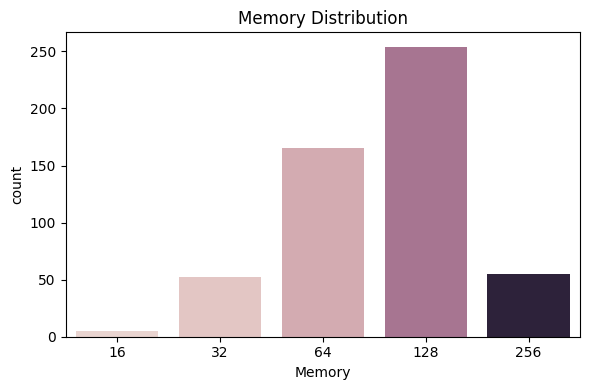

Memory
128    254
64     165
256     55
32      52
16       5
Name: count, dtype: int64

In [12]:
# Memory
fig = plt.figure(figsize=(6, 4))

# Countplot
ax1 = sns.countplot(data=df, x='Memory', hue='Memory', legend=False)
plt.title("Memory Distribution")

plt.tight_layout()
plt.show()
display(df['Memory'].value_counts())

>Insights

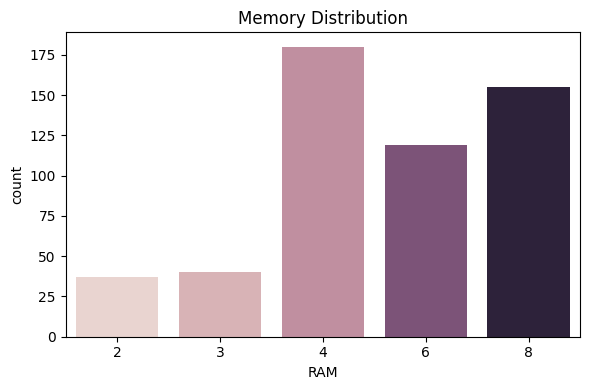

RAM
4    180
8    155
6    119
3     40
2     37
Name: count, dtype: int64

In [13]:
# RAM
fig = plt.figure(figsize=(6, 4))

# Countplot
ax = sns.countplot(data=df, x='RAM', hue='RAM', legend=False)
plt.title("Memory Distribution")

plt.tight_layout()
plt.show()
display(df['RAM'].value_counts())

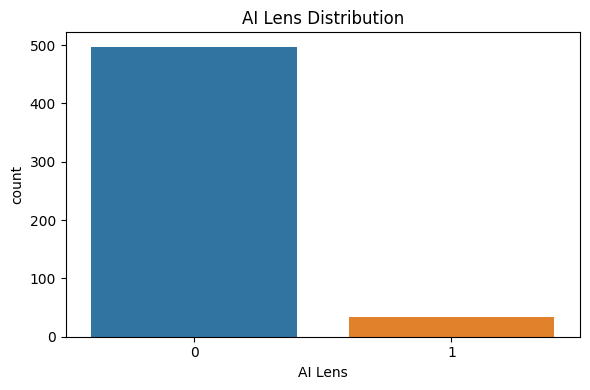

AI Lens
0    497
1     34
Name: count, dtype: int64

In [14]:
# AI Lens
fig = plt.figure(figsize=(6, 4))

# Countplot
ax = sns.countplot(data=df, x='AI Lens', hue='AI Lens', legend=False)
plt.title("AI Lens Distribution")

plt.tight_layout()
plt.show()
display(df['AI Lens'].value_counts())

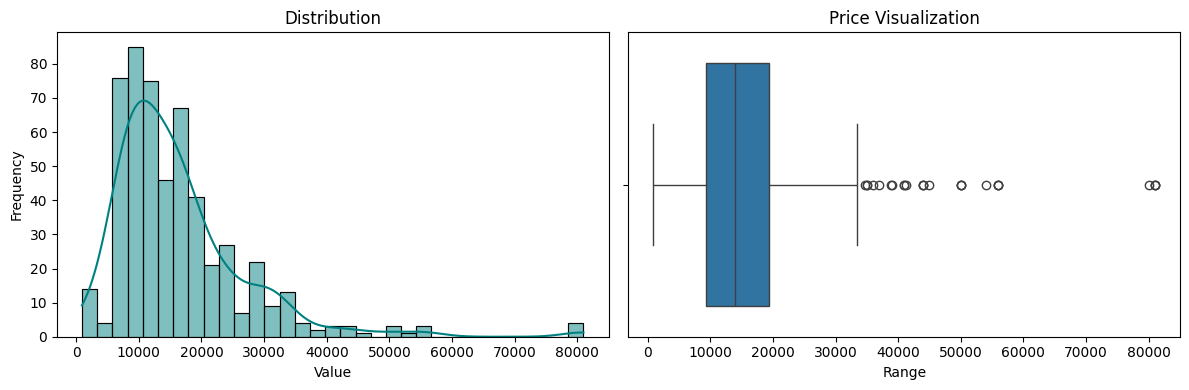

In [15]:
# Price
fig = plt.figure(figsize=(12, 4))

# Histogram
plt.subplot(1, 2, 1)
ax1 = sns.histplot(data=df, x='Price', color='teal', kde=True)
ax1.set_title('Distribution')
ax1.set_xlabel('Value')
ax1.set_ylabel('Frequency')

plt.subplot(1, 2, 2)
ax2 = sns.boxplot(data=df, x='Price')
ax2.set_title('Outliars')
ax2.set_xlabel('Range')

plt.title("Price Visualization")
plt.tight_layout()
plt.show()

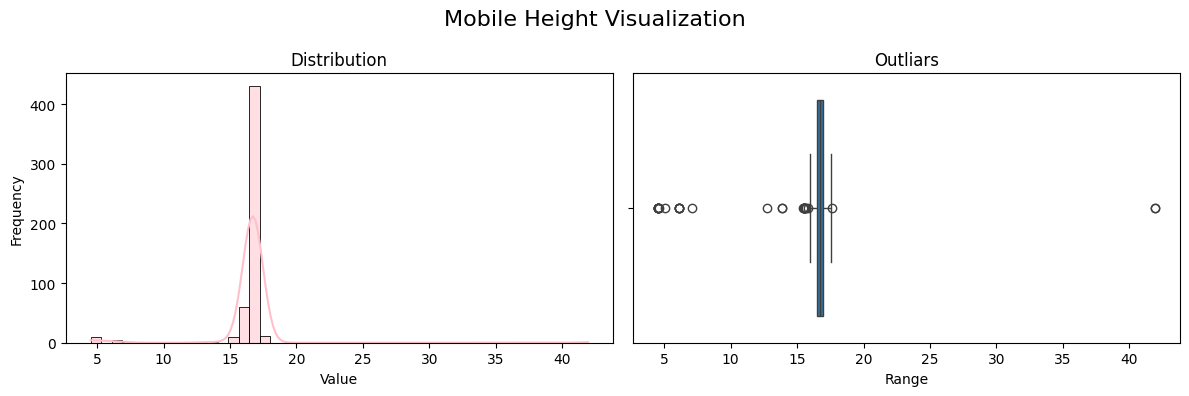

In [16]:
# Mobile Height
fig = plt.figure(figsize=(12, 4))

# Histogram
plt.subplot(1, 2, 1)
ax1 = sns.histplot(data=df, x='Mobile Height', color='pink', kde=True)
ax1.set_title('Distribution')
ax1.set_xlabel('Value')
ax1.set_ylabel('Frequency')

plt.subplot(1, 2, 2)
ax2 = sns.boxplot(data=df, x='Mobile Height')
ax2.set_title('Outliars')
ax2.set_xlabel('Range')

fig.suptitle("Mobile Height Visualization", fontsize=16)
plt.tight_layout()
plt.show()


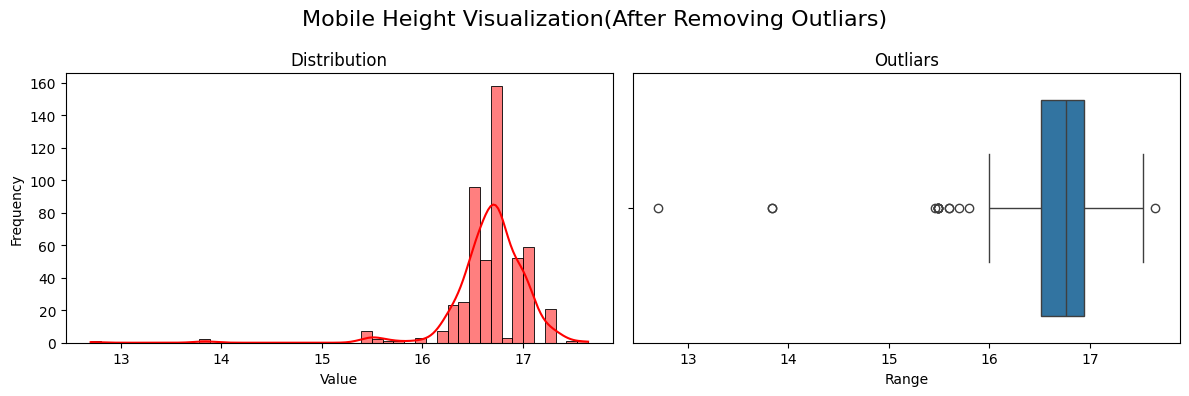

In [17]:
# After cleaning and removing outliars
df = df[(df['Mobile Height'] > 10) & (df['Mobile Height'] < 20)].copy()
fig = plt.figure(figsize=(12, 4))

# Histogram
plt.subplot(1, 2, 1)
ax1 = sns.histplot(data=df, x='Mobile Height', color='red', kde=True)
ax1.set_title('Distribution')
ax1.set_xlabel('Value')
ax1.set_ylabel('Frequency')

plt.subplot(1, 2, 2)
ax2 = sns.boxplot(data=df, x='Mobile Height')
ax2.set_title('Outliars')
ax2.set_xlabel('Range')

fig.suptitle("Mobile Height Visualization(After Removing Outliars)", fontsize=16)
plt.tight_layout()
plt.show()

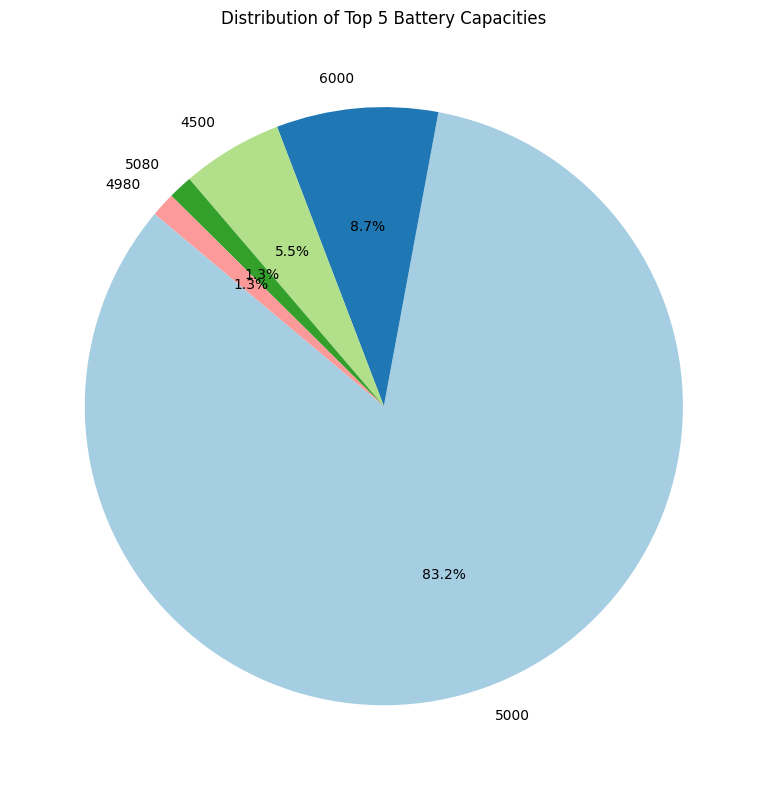

In [18]:
# Battery 
top_batteries = df['Battery'].value_counts().head()
plt.figure(figsize=(8, 8))
# Pie Chart
plt.pie(top_batteries, labels=top_batteries.index, autopct='%1.1f%%', startangle=140, colors=plt.cm.Paired.colors)
plt.title('Distribution of Top 5 Battery Capacities')
plt.tight_layout()
plt.show()

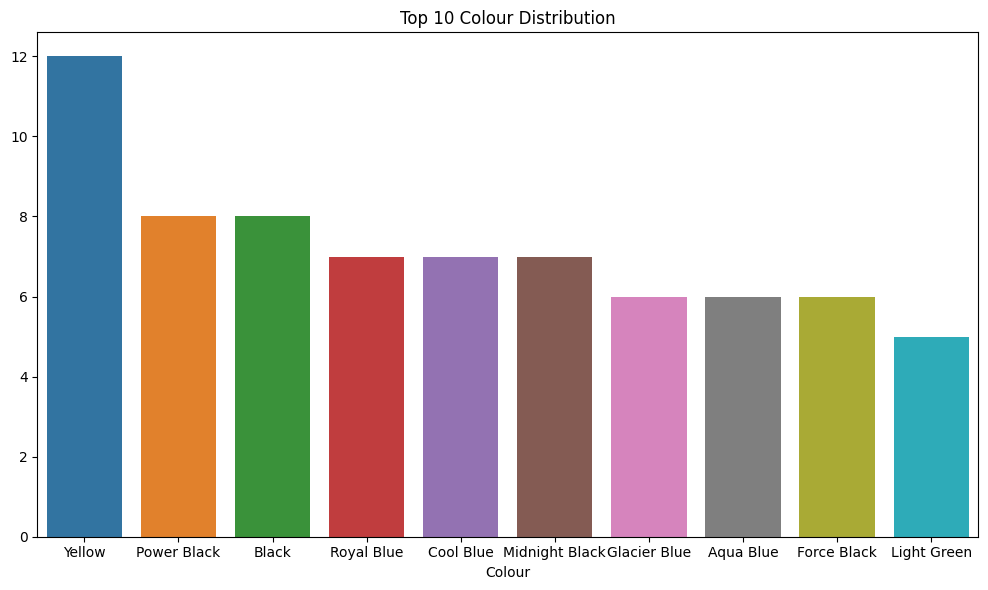

Colour
Yellow            12
Power Black        8
Black              8
Royal Blue         7
Cool Blue          7
Midnight Black     7
Glacier Blue       6
Aqua Blue          6
Force Black        6
Light Green        5
Name: count, dtype: int64

In [19]:
# Color
fig = plt.figure(figsize=(10, 6))
top10_df = df['Colour'].value_counts().head(10)

# Bar plot
ax = sns.barplot(x=top10_df.index, y=top10_df.values, hue=top10_df.index)
plt.title("Top 10 Colour Distribution")

plt.tight_layout()
plt.show()
display(top10_df)

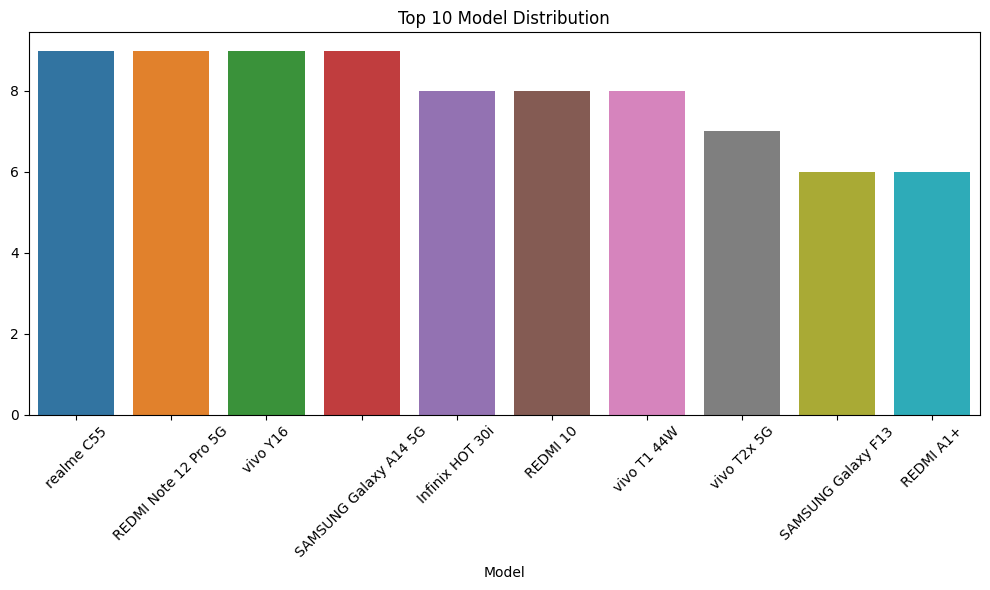

Model
realme C55               9
REDMI Note 12 Pro 5G     9
vivo Y16                 9
SAMSUNG Galaxy A14 5G    9
Infinix HOT 30i          8
REDMI 10                 8
vivo T1 44W              8
vivo T2x 5G              7
SAMSUNG Galaxy F13       6
REDMI A1+                6
Name: count, dtype: int64

In [20]:
# Model
fig = plt.figure(figsize=(10, 6))
top10_df = df['Model'].value_counts().head(10)

# Bar plot
ax = sns.barplot(x=top10_df.index, y=top10_df.values, hue=top10_df.index)
plt.title("Top 10 Model Distribution")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()
display(top10_df)

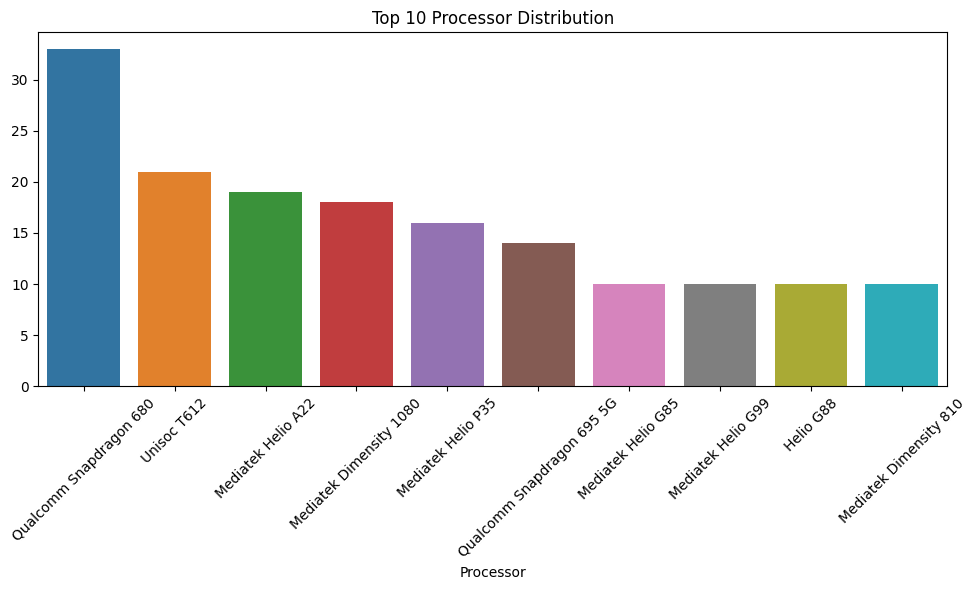

Processor
Qualcomm Snapdragon 680       33
Unisoc T612                   21
Mediatek Helio A22            19
Mediatek Dimensity 1080       18
Mediatek Helio P35            16
Qualcomm Snapdragon 695 5G    14
Mediatek Helio G85            10
Mediatek Helio G99            10
Helio G88                     10
Mediatek Dimensity 810        10
Name: count, dtype: int64

In [21]:
# Processor
fig = plt.figure(figsize=(10, 6))
top10_df = df['Processor'].value_counts().head(10)

# Bar plot
ax = sns.barplot(x=top10_df.index, y=top10_df.values, hue=top10_df.index)
plt.title("Top 10 Processor Distribution")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()
display(top10_df)

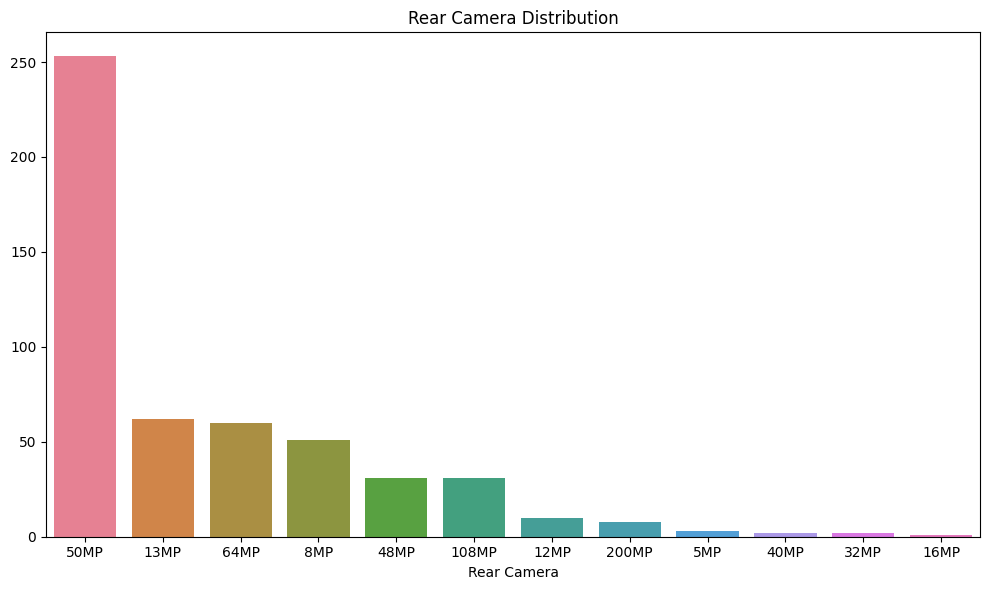

Rear Camera
50MP     253
13MP      62
64MP      60
8MP       51
48MP      31
108MP     31
12MP      10
200MP      8
5MP        3
40MP       2
32MP       2
16MP       1
Name: count, dtype: int64

In [22]:
# Rear Camera
fig = plt.figure(figsize=(10, 6))
top10_df = df['Rear Camera'].value_counts()

# Bar plot
ax = sns.barplot(x=top10_df.index, y=top10_df.values, hue=top10_df.index)
plt.title("Rear Camera Distribution")

plt.tight_layout()
plt.show()
display(top10_df)

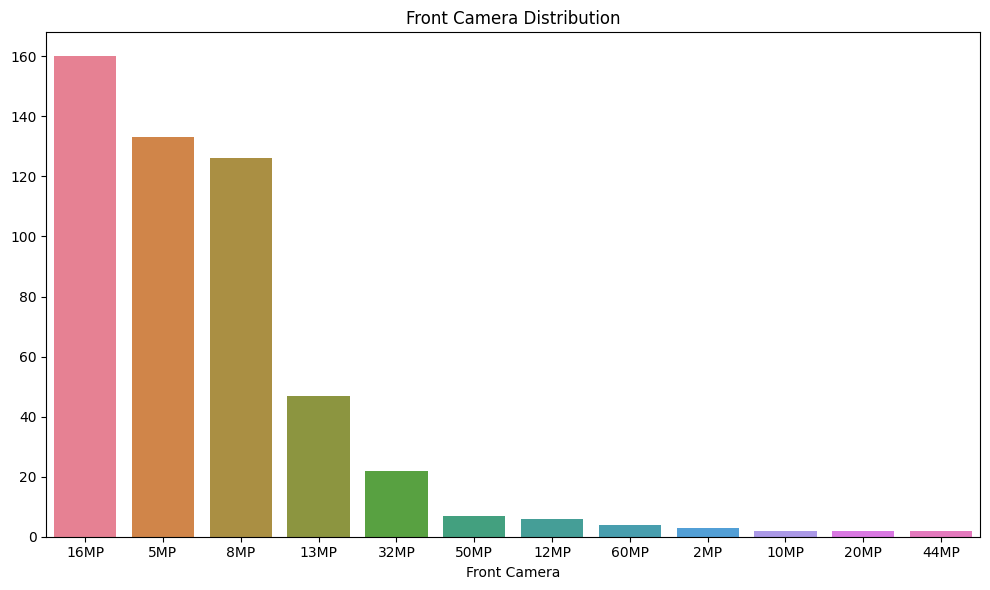

Front Camera
16MP    160
5MP     133
8MP     126
13MP     47
32MP     22
50MP      7
12MP      6
60MP      4
2MP       3
10MP      2
20MP      2
44MP      2
Name: count, dtype: int64

In [23]:
# Front Camera
fig = plt.figure(figsize=(10, 6))
top10_df = df['Front Camera'].value_counts()

# Bar plot
ax = sns.barplot(x=top10_df.index, y=top10_df.values, hue=top10_df.index)
plt.title("Front Camera Distribution")

plt.tight_layout()
plt.show()
display(top10_df)

## Bivariate Analysis

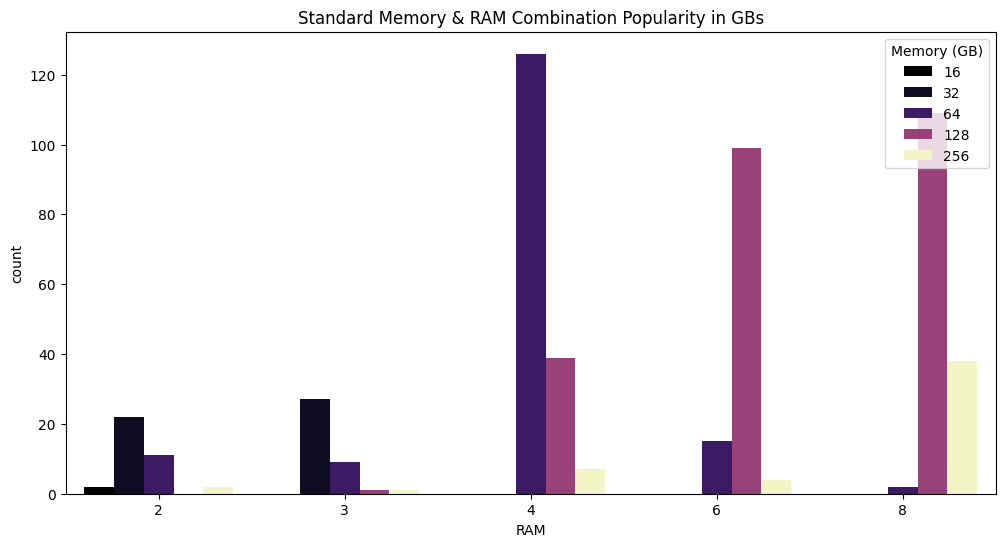

In [24]:
# RAM vs Memory
plt.figure(figsize=(12, 6))
sns.countplot(data=df, x='RAM', hue='Memory', palette='magma')
plt.title('Standard Memory & RAM Combination Popularity in GBs')
plt.legend(title='Memory (GB)', loc='upper right')
plt.show()


C:\Users\ashwi\AppData\Local\Temp\ipykernel_10260\62785470.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_top_proc, x='RAM', y='Processor', palette='coolwarm', order=top_10_names, errorbar=None)


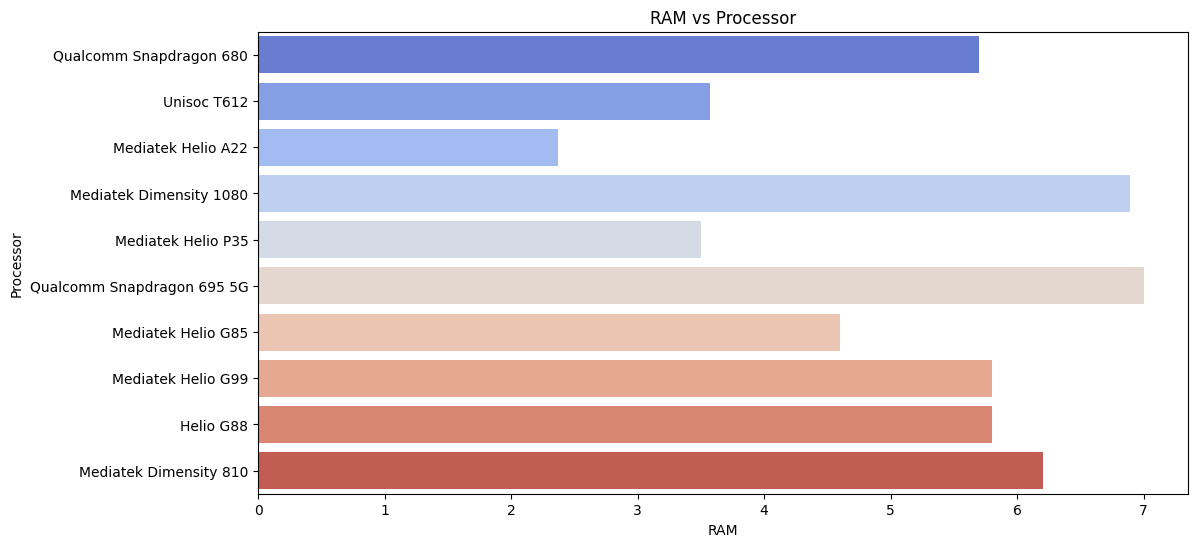

In [25]:
# RAM vs Processor - need fix
top_10_names = df['Processor'].value_counts().head(10).index
df_top_proc = df[df['Processor'].isin(top_10_names)]

plt.figure(figsize=(12, 6))
sns.barplot(data=df_top_proc, x='RAM', y='Processor', palette='coolwarm', order=top_10_names, errorbar=None)
plt.title('RAM vs Processor')
plt.show()

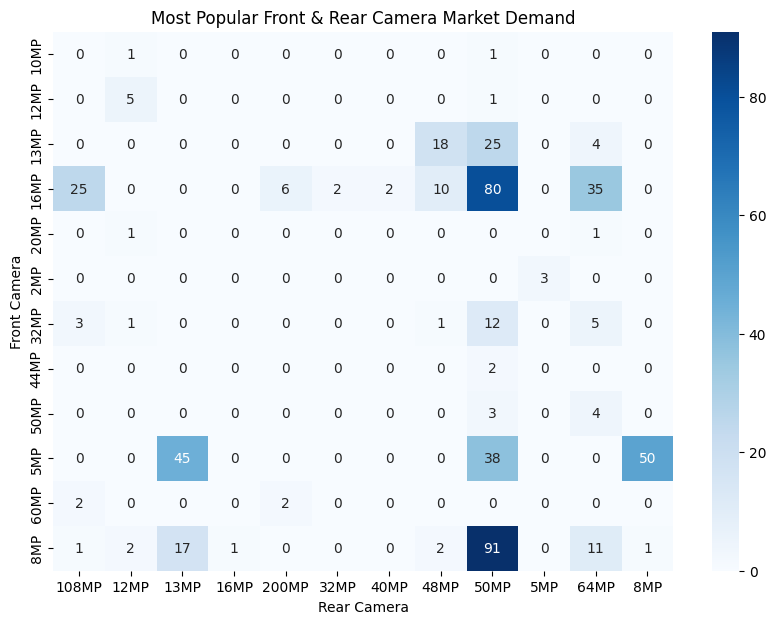

In [26]:
# Relationship between Front and Rear Camera
plt.figure(figsize=(10, 7))
front_rear_camera_table = pd.crosstab(df['Front Camera'], df['Rear Camera'])

# Heatmap
sns.heatmap(front_rear_camera_table, annot=True, fmt='d', cmap='Blues')
plt.title('Most Popular Front & Rear Camera Market Demand')
plt.show()

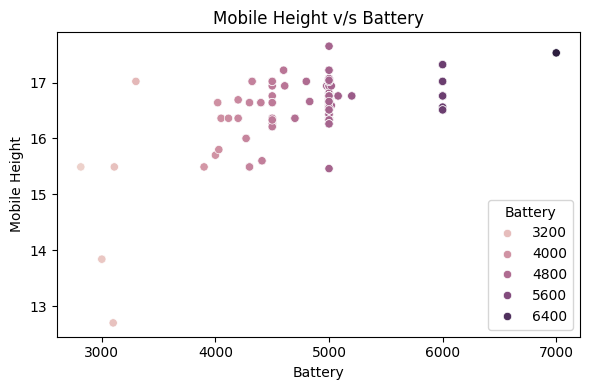

In [27]:
# Battery v/s Mobile Height
fig = plt.figure(figsize=(6, 4))

# # Scatter plot
ax = sns.scatterplot(data=df, x='Battery', y='Mobile Height', hue='Battery')
plt.title("Mobile Height v/s Battery")

plt.tight_layout()
plt.show()

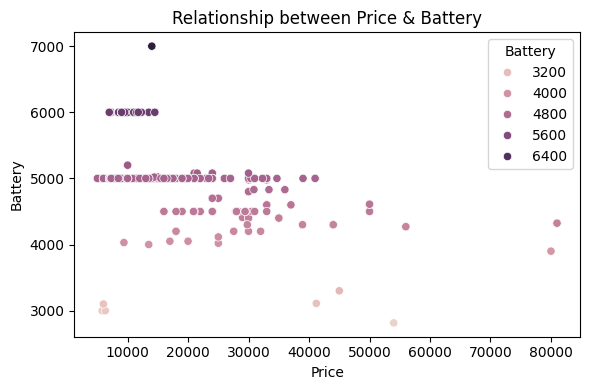

In [28]:
# Battery v/s Price
fig = plt.figure(figsize=(6, 4))

# # Scatter plot
ax = sns.scatterplot(data=df, x='Price', y='Battery', hue='Battery')
plt.title("Relationship between Price & Battery")

plt.tight_layout()
plt.show()

C:\Users\ashwi\AppData\Local\Temp\ipykernel_10260\212587922.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_top_proc, x='Processor', y='Price', palette='coolwarm', order=top_10_names)


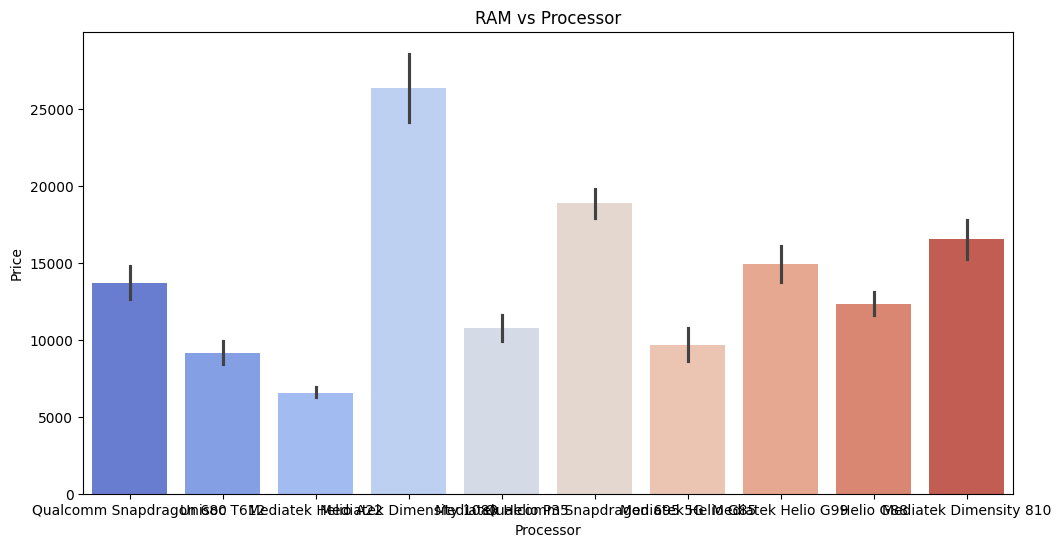

In [29]:
# Processor vs Price
top_10_names = df['Processor'].value_counts().head(10).index
df_top_proc = df[df['Processor'].isin(top_10_names)]

plt.figure(figsize=(12, 6))
sns.barplot(data=df_top_proc, x='Processor', y='Price', palette='coolwarm', order=top_10_names)
plt.title('RAM vs Processor')
plt.show()

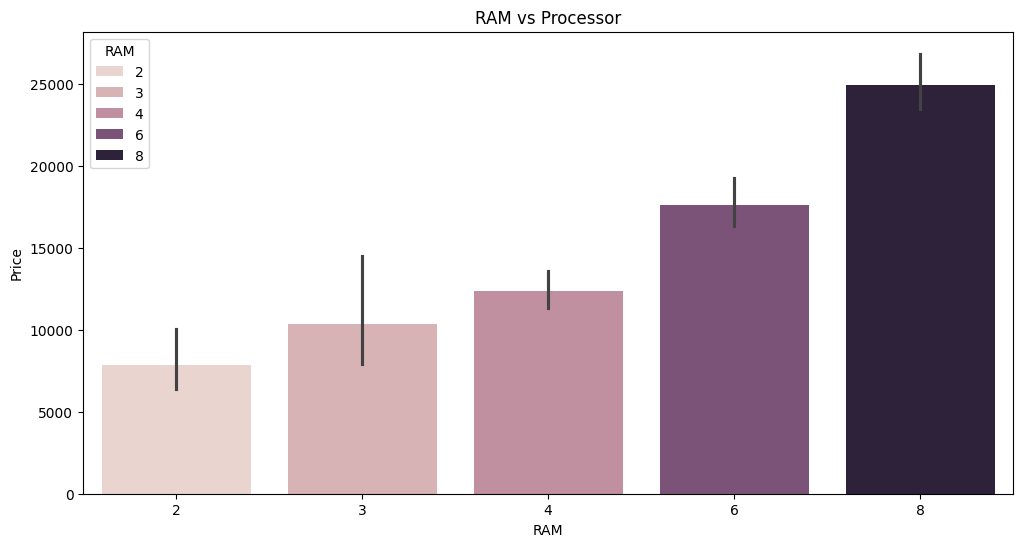

In [30]:
# RAM vs Price
plt.figure(figsize=(12, 6))
sns.barplot(data=df, x='RAM', y='Price', hue='RAM')
plt.title('RAM vs Processor')
plt.show()

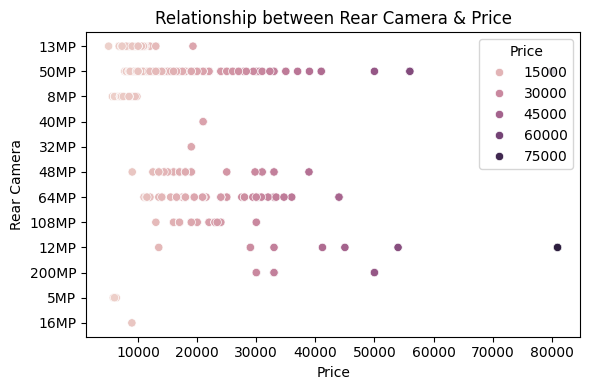

In [31]:
# Rear Camera vs Price
fig = plt.figure(figsize=(6, 4))

# # Scatter plot
ax = sns.scatterplot(data=df, x='Price', y='Rear Camera', hue='Price')
plt.title("Relationship between Rear Camera & Price")

plt.tight_layout()
plt.show()

## Multivariate Analysis

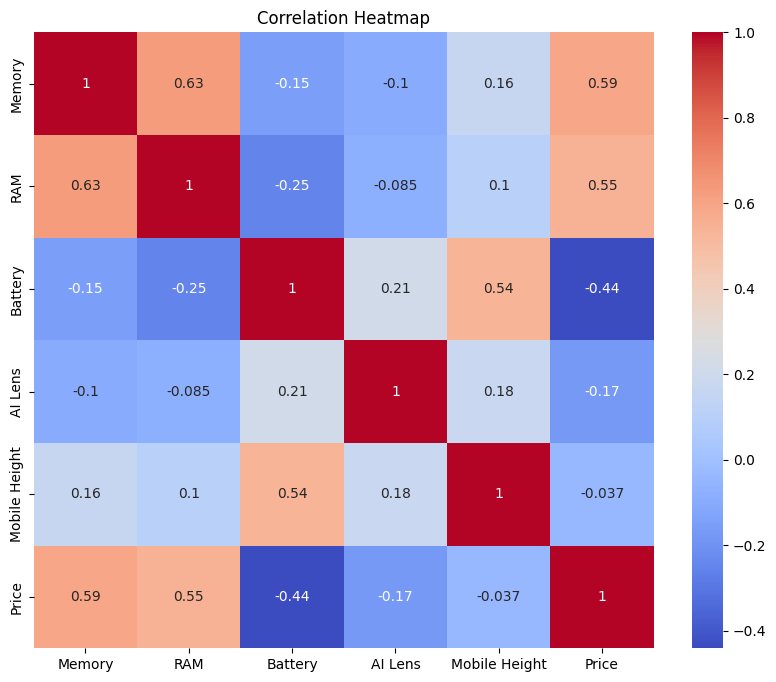

In [32]:
# Heatmap
corr = df.select_dtypes(include='number').corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, cmap='coolwarm')

plt.title('Correlation Heatmap')
plt.show()

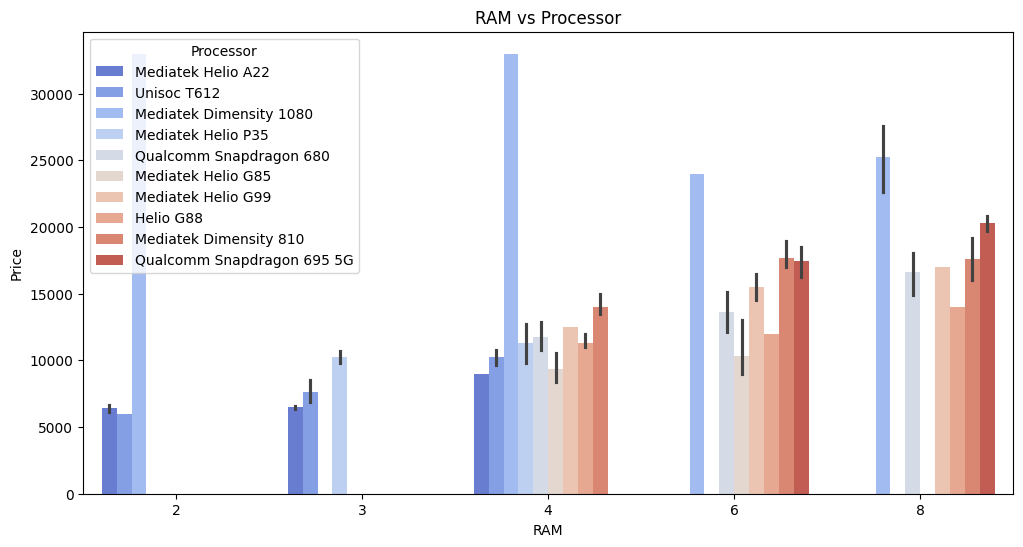

In [33]:
# RAM vs Price with Processor
top_10_names = df['Processor'].value_counts().head(10).index
df_top_proc = df[df['Processor'].isin(top_10_names)]

plt.figure(figsize=(12, 6))
sns.barplot(data=df_top_proc, x='RAM', y='Price', hue='Processor', palette='coolwarm')
plt.title('RAM vs Processor')
plt.show()


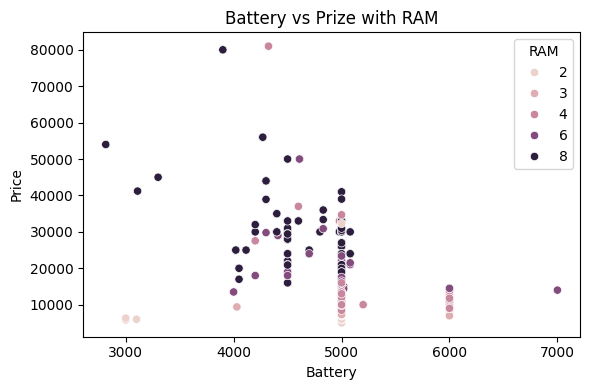

In [34]:
# Battery vs Prize with RAM
fig = plt.figure(figsize=(6, 4))

# # Scatter plot
ax = sns.scatterplot(data=df, x='Battery', y='Price', hue='RAM')
plt.title("Battery vs Prize with RAM")

plt.tight_layout()
plt.show()

## Feature Engineering

In [35]:
def priceCategory(price):
    if price < 10000:
        return 'Budget'
    elif price <= 25000:
        return 'Mid-Range'
    else:
        return 'Flagship'

# def mobileSizeFilter(height):
#     if height < 16:
#         return "Compact"
#     elif 16 <= height >= 17:
#         return "Standard"
#     else:
#         return "Large"

# Setting up budget range
df['Price Segment'] = df['Price'].apply(priceCategory)
 
# Device size
# df['Device Size'] = df['Mobile Height'].apply(mobileSizeFilter)

# Processor brand
df['Processor Brand'] = df['Processor'].str.split().str[0]

# Brand name
df['Mobile Brand'] = df['Model'].str.split().str[0]

# Price per GB RAM
df['Price_per_GB_RAM'] = df['Price'] / df['RAM']

df.head()

,Model,Colour,Memory,RAM,Battery,Rear Camera,Front Camera,AI Lens,Mobile Height,Processor,Price,Price Segment,Processor Brand,Mobile Brand,Price_per_GB_RAM
0,Infinix SMART 7,Night Black,64,4,6000,13MP,5MP,1,16.76,Unisoc Spreadtrum SC9863A1,7299,Budget,Unisoc,Infinix,1824.750
1,Infinix SMART 7,Azure Blue,64,4,6000,13MP,5MP,1,16.76,Unisoc Spreadtrum SC9863A1,7299,Budget,Unisoc,Infinix,1824.750
2,MOTOROLA G32,Mineral Gray,128,8,5000,50MP,16MP,0,16.64,Qualcomm Snapdragon 680,11999,Mid-Range,Qualcomm,MOTOROLA,1499.875
3,POCO C50,Royal Blue,32,2,5000,8MP,5MP,0,16.56,Mediatek Helio A22,5649,Budget,Mediatek,POCO,2824.500
4,Infinix HOT 30i,Marigold,128,8,5000,50MP,5MP,1,16.76,G37,8999,Budget,G37,Infinix,1124.875
